# K-Nearest Neighbors (KNN) Classification

In [22]:
#import libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from matplotlib.colors import ListedColormap

In [23]:
iris = load_iris()
x = iris.data[:,:2]
y = iris.target

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=42)

 Normalizing features

In [25]:
scaler=StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

 Training KNN for different K values

In [26]:
for k in range(1,15):
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train,y_train)
    y_pred = knn.predict(x_test)
    acc = accuracy_score(y_test,y_pred)
    print(f"K={k}-Accuracy:{acc:.2f}") # getting accuracy

K=1-Accuracy:0.71
K=2-Accuracy:0.73
K=3-Accuracy:0.84
K=4-Accuracy:0.76
K=5-Accuracy:0.82
K=6-Accuracy:0.82
K=7-Accuracy:0.80
K=8-Accuracy:0.78
K=9-Accuracy:0.82
K=10-Accuracy:0.76
K=11-Accuracy:0.73
K=12-Accuracy:0.69
K=13-Accuracy:0.73
K=14-Accuracy:0.69


COnfusion matrix

Accuracy with K=3: 0.84


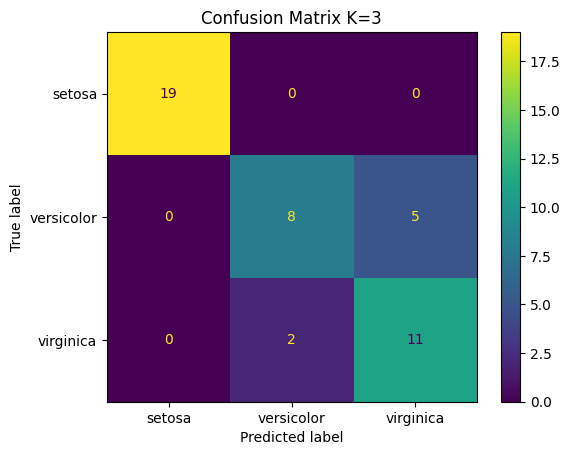

In [27]:
k = 3
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy with K={k}: {acc:.2f}")
cm=confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=iris.target_names)
disp.plot()
plt.title(f"Confusion Matrix K={k}")
plt.show()

Visualizing decision boundaries 

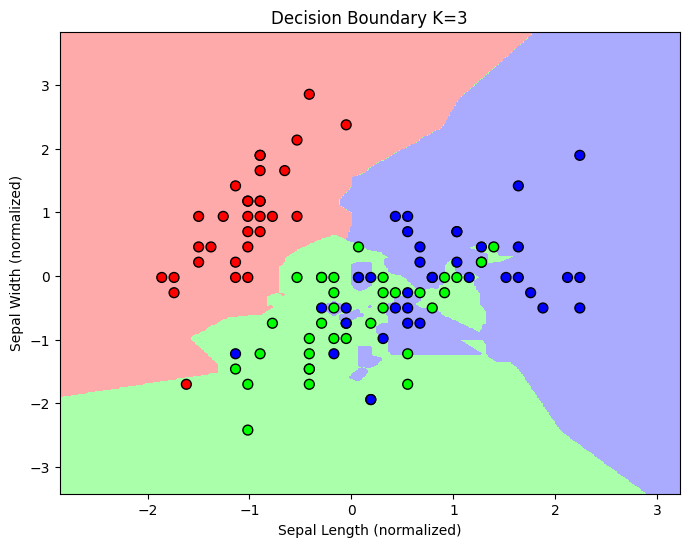

In [29]:
def plot_db(x,y,model,title="Decision Boundary"):
    h=0.02
    xmin, xmax = x[:,0].min()-1, x[:,0].max()+1
    ymin, ymax = x[:,1].min()-1, x[:,1].max()+1
    xx, yy = np.meshgrid(np.arange(xmin, xmax, h),np.arange(ymin, ymax, h))
    z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    z = z.reshape(xx.shape)

    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, z, cmap=cmap_light)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=50)
    plt.title(title)
    plt.xlabel("Sepal Length (normalized)")
    plt.ylabel("Sepal Width (normalized)")
    plt.show()

# Plot using the training set
plot_db(x_train, y_train, knn, title=(f"Decision Boundary K={k}"))